# 03 — ABSA gold v4: XLM-R (candidato principal) vs BERT multilingual + TextCNN (base oficial)

**Bitácora final.** Compara el **candidato principal XLM-R + TextCNN** contra la **arquitectura base
oficial del PPI (BERT multilingual + TextCNN)** y un baseline clásico (TF-IDF + LogReg), sobre el
**gold v4** (misma partición, mismas etiquetas y taxonomía). Los hiperparámetros de la clase negativa
(`NEG_BOOST`, `FOCAL_GAMMA`) se **seleccionan por validación**, nunca mirando el test.

- **Spec:** [`specs/modulo-absa-fase2.md`](../specs/modulo-absa-fase2.md)
- **Umbral:** F1-macro ≥ 0.70 con mínimos por clase (neg F1 ≥ 0.60 y recall ≥ 0.60; neu F1 ≥ 0.60).

**Criterio de cierre:** si XLM-R cumple la spec de forma **estable** (≥0.70, mínimos por clase, std ≤ 0.03
en 5 semillas), se adopta como modelo final y genera la matriz ABSA. Si no, se reporta como mejora
exploratoria y se mantiene la versión base defendible.

### Ejecución
`RUN_TRAINING=False` por defecto con **auto-fallback**: si faltan artefactos, entrena solo. *Restart & Run All*.

In [1]:
import os, gc
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")   # reduce fragmentacion -> menos OOM
from pathlib import Path
import json, random, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 220)

BASE = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA, REP, VIS = BASE / "data", BASE / "outputs" / "reports", BASE / "outputs" / "visualizations"
MODELS_DIR, PRED_DIR, MATR_DIR = BASE / "models", BASE / "outputs" / "predictions", BASE / "outputs" / "matrices"
for d in (REP, VIS, MODELS_DIR, PRED_DIR, MATR_DIR): d.mkdir(parents=True, exist_ok=True)
LABELS = ["negativo", "neutro", "positivo"]; L2I = {l: i for i, l in enumerate(LABELS)}; I2L = {i: l for l, i in L2I.items()}
COLOR = {"negativo": "#d62728", "neutro": "#7f7f7f", "positivo": "#2ca02c"}

VER = "v4"
RUN_TRAINING = False
MODEL_BERT, MODEL_XLMR = "bert-base-multilingual-cased", "xlm-roberta-base"
MAX_LEN, BATCH, EPOCHS = 192, 4, 10   # batch 4 + checkpointing para no exceder 8GB (RTX 2070)
LR, WEIGHT_DECAY, WARMUP_RATIO, PATIENCE, DROPOUT = 2e-5, 0.10, 0.10, 3, 0.40
CNN_FILTERS, CNN_KERNELS = 128, (2, 3, 4)
SEEDS = [42, 7, 123, 2024, 77]
LABEL_SMOOTHING = 0.1
CALIBRAR_DECISION = True
USE_GRADIENT_CHECKPOINTING = True   # reduce mucho la memoria de activaciones (cabe en 8GB)
TH_MACRO, TH_NEG_F1, TH_NEG_REC, TH_NEU_F1 = 0.70, 0.60, 0.60, 0.60
# --- Seleccion de hiperparametros de la clase negativa POR VALIDACION ---
SELECCIONAR_HP = True
NEG_BOOST_GRID = [1.2, 1.8]
FOCAL_GRID = [2.0]               # focal fijo; se rankea NEG_BOOST por validacion (2 combos, rapido)
SEARCH_EPOCHS = 3                # epocas reducidas solo para rankear HP
NEG_BOOST_DEFAULT, FOCAL_DEFAULT = 1.6, 2.0   # si SELECCIONAR_HP=False
MAX_CORPUS_INFER = None

ART = {"hp": REP / f"hp_seleccion_{VER}.csv",
       "det_xlmr": REP / f"resultados_xlmr_{VER}.csv", "det_bert": REP / f"resultados_bert_{VER}.csv",
       "resumen": REP / f"resumen_modelos_{VER}.csv", "comp": REP / f"comparacion_modelos_{VER}.csv",
       "clsrep": REP / f"classification_report_{VER}.csv", "hist": REP / f"historial_entrenamiento_{VER}.csv",
       "asp_xlmr": REP / f"por_aspecto_xlmr_{VER}.csv", "asp_bert": REP / f"por_aspecto_bert_{VER}.csv",
       "preds_test": PRED_DIR / f"predicciones_test_{VER}.csv", "matriz": MATR_DIR / "matriz_destino_aspecto_sentimiento.csv"}
def artefactos_existen(): return all(p.exists() for p in ART.values())
print("BASE:", BASE, "| RUN_TRAINING:", RUN_TRAINING, "| artefactos:", artefactos_existen())

BASE: c:\Users\danie\Documents\Proyectos\ABSA_Turismo_Fase2_V3 | RUN_TRAINING: False | artefactos: False


## 1. Carga del gold v4 y splits

In [2]:
gold = pd.read_csv(DATA / f"gold_set_{VER}.csv", encoding="utf-8-sig")
train = pd.read_csv(DATA / f"train_gold_{VER}.csv", encoding="utf-8-sig")
val   = pd.read_csv(DATA / f"val_gold_{VER}.csv", encoding="utf-8-sig")
test  = pd.read_csv(DATA / f"test_gold_{VER}.csv", encoding="utf-8-sig")
for d in (gold, train, val, test):
    d["label"] = d["label"].astype(str).str.lower().str.strip()
    if "input_modelo" not in d.columns or d["input_modelo"].isna().any():
        d["input_modelo"] = "aspecto: " + d["aspecto"].astype(str) + " reseña: " + d["text_clean"].astype(str)
print(f"gold {VER}: {len(gold)} | reseñas únicas {gold['review_uid'].nunique()}")
for nm, d in [("train", train), ("val", val), ("test", test)]: print(f"{nm:5s}: {len(d):5d}")

gold v4: 4045 | reseñas únicas 2007
train:  2826
val  :   609
test :   610


## 2. Verificación de no fuga por `review_uid`

In [3]:
s = {n: set(d.review_uid) for n, d in [("tr", train), ("va", val), ("te", test)]}
fuga = {"tr∩va": len(s["tr"]&s["va"]), "tr∩te": len(s["tr"]&s["te"]), "va∩te": len(s["va"]&s["te"])}
print(fuga); assert sum(fuga.values()) == 0; print("✅ Sin fuga.")

{'tr∩va': 0, 'tr∩te': 0, 'va∩te': 0}
✅ Sin fuga.


## 3. Distribución por split (polaridad y aspecto)

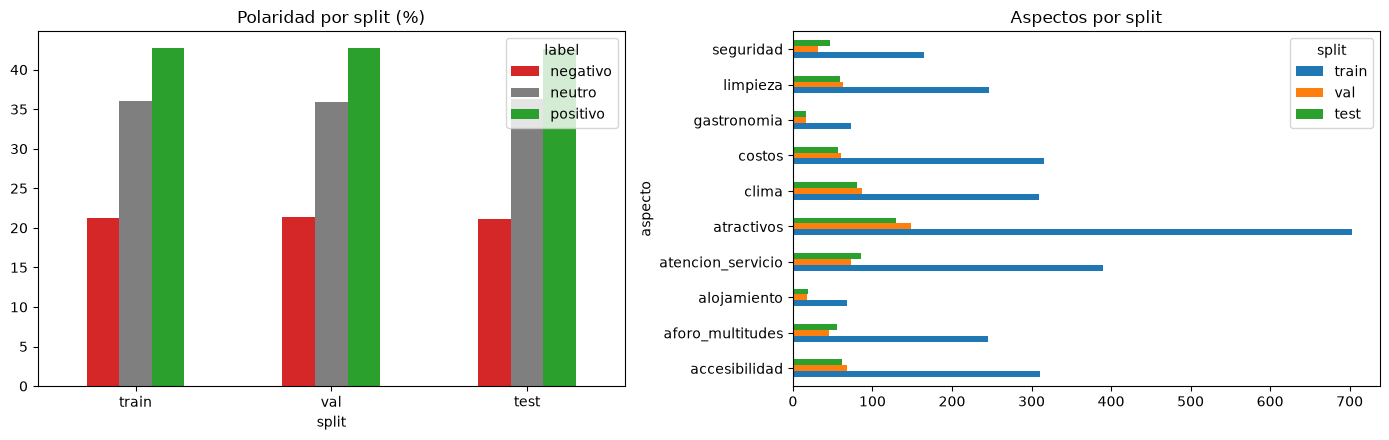

In [4]:
alld = pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")])
def tabla(col): return alld.groupby([col,"split"]).size().unstack("split", fill_value=0).reindex(columns=["train","val","test"], fill_value=0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
(tabla("label")/tabla("label").sum()*100).reindex(LABELS).T.plot(kind="bar", ax=ax[0], color=[COLOR[l] for l in LABELS])
ax[0].set_title("Polaridad por split (%)"); ax[0].tick_params(axis="x", rotation=0)
tabla("aspecto").plot(kind="barh", ax=ax[1]); ax[1].set_title("Aspectos por split")
plt.tight_layout(); plt.show()

## 4. Arquitectura, loss enfocada a negativo y calibración

Encoder Transformer (BERT-mult o XLM-R) → TextCNN (kernels 2/3/4) → clasificador. Loss = Focal +
class weights con refuerzo a negativa (`NEG_BOOST`) + label smoothing. La decisión se **calibra en
validación** (sesgo por clase que maximiza F1-macro), nunca en test.

In [5]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); USE_AMP = torch.cuda.is_available()

class ABSADataset(Dataset):
    def __init__(s, texts, labels, tok): s.t=list(texts); s.l=list(labels); s.tok=tok
    def __len__(s): return len(s.t)
    def __getitem__(s, i):
        e = s.tok(str(s.t[i]), add_special_tokens=True, max_length=MAX_LEN, padding="max_length", truncation=True, return_attention_mask=True, return_tensors="pt")
        return {"input_ids": e["input_ids"].squeeze(0), "attention_mask": e["attention_mask"].squeeze(0), "labels": torch.tensor(L2I[s.l[i]], dtype=torch.long)}

class TextCNN(nn.Module):
    def __init__(s, model_name):
        super().__init__(); s.bert = AutoModel.from_pretrained(model_name)
        if USE_GRADIENT_CHECKPOINTING: s.bert.config.use_cache=False; s.bert.gradient_checkpointing_enable()
        h = s.bert.config.hidden_size
        s.convs = nn.ModuleList([nn.Conv1d(h, CNN_FILTERS, k) for k in CNN_KERNELS])
        s.drop = nn.Dropout(DROPOUT); s.fc = nn.Linear(CNN_FILTERS*len(CNN_KERNELS), 3)
    def forward(s, ids, mask):
        x = s.bert(input_ids=ids, attention_mask=mask).last_hidden_state.transpose(1, 2)
        return s.fc(s.drop(torch.cat([torch.max(torch.relu(c(x)), 2).values for c in s.convs], 1)))

class FocalLoss(nn.Module):
    def __init__(s, weight, gamma): super().__init__(); s.w=weight; s.g=gamma
    def forward(s, logits, y):
        ce = nn.functional.cross_entropy(logits, y, weight=s.w, reduction="none", label_smoothing=LABEL_SMOOTHING)
        return (((1-torch.exp(-ce))**s.g)*ce).mean()

def class_weights(labels, neg_boost):
    c = pd.Series(labels).value_counts().reindex(LABELS, fill_value=0); tot=c.sum()
    w = [tot/(3*c[l]) if c[l]>0 else 0.0 for l in LABELS]; w[L2I["negativo"]] *= neg_boost
    return torch.tensor(w, dtype=torch.float).to(DEVICE)

def metrics(trues, preds):
    pr, rc, f1, _ = precision_recall_fscore_support(trues, preds, labels=LABELS, average=None, zero_division=0)
    _, _, mf1, _ = precision_recall_fscore_support(trues, preds, labels=LABELS, average="macro", zero_division=0)
    o = {"f1_macro": mf1, "accuracy": accuracy_score(trues, preds)}
    for i, l in enumerate(LABELS): o[f"f1_{l}"]=f1[i]; o[f"recall_{l}"]=rc[i]
    return o

def apply_bias(probs, bias): return [I2L[i] for i in (np.log(probs+1e-9)+bias).argmax(1)]
def best_bias(vp, vt):
    if not CALIBRAR_DECISION: return np.zeros(3)
    logp=np.log(vp+1e-9); g=np.arange(-1.2,1.21,0.2); best,bb=-1,np.zeros(3)
    for b0 in g:
        for b1 in g:
            b=np.array([b0,b1,0.0]); f=metrics(vt,[I2L[i] for i in (logp+b).argmax(1)])["f1_macro"]
            if f>best: best,bb=f,b
    return bb
print("DEVICE:", DEVICE)

DEVICE: cuda


## 5. Selección de hiperparámetros por validación + entrenamiento

`train_one` entrena una semilla. La selección de `(NEG_BOOST, FOCAL_GAMMA)` se hace **maximizando
F1-macro en validación** con épocas reducidas; los valores elegidos se usan para entrenar las 5 semillas
de **ambos** modelos (XLM-R principal y BERT base) bajo el mismo protocolo.

In [6]:
from tqdm.auto import tqdm   # barra de progreso por época/semilla

def set_seed(sd):
    random.seed(sd); np.random.seed(sd); torch.manual_seed(sd)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(sd)

def predict(model, loader, loss_fn=None):
    model.eval(); P, T, tot = [], [], 0.0
    with torch.no_grad():
        for b in loader:
            ids, mask, y = b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE), b["labels"].to(DEVICE)
            with torch.autocast("cuda", enabled=USE_AMP):
                lo = model(ids, mask)
                if loss_fn is not None: tot += loss_fn(lo, y).item()
            P.append(torch.softmax(lo.float(),1).cpu().numpy()); T += [I2L[i] for i in y.cpu().numpy()]
    return np.concatenate(P), T, tot/max(len(loader),1)

def train_one(seed, model_name, neg_boost, focal_gamma, epochs=EPOCHS, record_history=False, save_tag=None):
    set_seed(seed); tok = AutoTokenizer.from_pretrained(model_name)
    tl = DataLoader(ABSADataset(train["input_modelo"], train["label"], tok), batch_size=BATCH, shuffle=True)
    vl = DataLoader(ABSADataset(val["input_modelo"], val["label"], tok), batch_size=BATCH)
    el = DataLoader(ABSADataset(test["input_modelo"], test["label"], tok), batch_size=BATCH)
    model = TextCNN(model_name).to(DEVICE); loss_fn = FocalLoss(class_weights(train["label"], neg_boost), focal_gamma)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = get_linear_schedule_with_warmup(opt, int(len(tl)*epochs*WARMUP_RATIO), len(tl)*epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP); best,bs,pat,hist = -1,None,0,[]
    short = model_name.split("-")[0]
    for ep in range(1, epochs+1):
        model.train(); run=0.0
        bar = tqdm(tl, desc=f"{short} | seed {seed} | época {ep}/{epochs}", leave=False, unit="batch")
        nbt = len(tl); cada = max(1, nbt // 4)
        for bi, b in enumerate(bar, 1):
            opt.zero_grad()
            with torch.autocast("cuda", enabled=USE_AMP):
                loss = loss_fn(model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)), b["labels"].to(DEVICE))
            scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(opt); scaler.update(); sch.step(); run += loss.item()
            bar.set_postfix(loss=f"{loss.item():.3f}")
            if bi % cada == 0 or bi == nbt:   # progreso visible dentro de la época (aunque falte ipywidgets)
                print(f"      {short} seed {seed} ép {ep}/{epochs}: batch {bi}/{nbt} ({bi*100//nbt}%) loss={loss.item():.3f}", flush=True)
        vp, vt, vloss = predict(model, vl, loss_fn); vf = metrics(vt, [I2L[i] for i in vp.argmax(1)])["f1_macro"]
        print(f"  [{short}] seed {seed} | época {ep}/{epochs} | val_f1={vf:.3f} | loss={run/len(tl):.3f}", flush=True)
        if record_history:
            tp_, tt_, _ = predict(model, tl); tf = metrics(tt_, [I2L[i] for i in tp_.argmax(1)])["f1_macro"]
            hist.append({"epoch": ep, "train_loss": run/len(tl), "val_loss": vloss, "train_f1_macro": tf, "val_f1_macro": vf})
        if vf > best: best,bs,pat = vf, {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            pat += 1
            if pat >= PATIENCE: break
    if bs: model.load_state_dict(bs)
    if save_tag: torch.save(bs, MODELS_DIR / f"modelo_{save_tag}.pt")
    tp, tt, _ = predict(model, el); vp, vtv, _ = predict(model, vl); del model, opt, scaler
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return tp, tt, vp, vtv, pd.DataFrame(hist)

def run_modelo(model_name, tag, neg_boost, focal_gamma):
    print(f"\n===== Entrenando {tag.upper()} ({model_name}) — {len(SEEDS)} semillas =====", flush=True)
    rows, probs, vprobs, tt0, vt0, hist0 = [], [], [], None, None, None
    for k, sd in enumerate(SEEDS):
        print(f"  [{tag}] semilla {sd} ({k+1}/{len(SEEDS)})", flush=True)
        tp, tt, vp, vtv, h = train_one(sd, model_name, neg_boost, focal_gamma, record_history=(k==0), save_tag=f"{tag}_seed{sd}_{VER}")
        tt0, vt0 = tt, vtv; probs.append(tp); vprobs.append(vp)
        if k==0: hist0 = h
        m = metrics(tt, [I2L[i] for i in tp.argmax(1)]); rows.append({"seed": sd, **{kk:round(v,4) for kk,v in m.items()}})
    det = pd.DataFrame(rows); ens=np.mean(probs,0); ensv=np.mean(vprobs,0)
    bias = best_bias(ensv, vt0); preds = apply_bias(ens, bias); em = metrics(tt0, preds)
    np.save(MODELS_DIR / f"_bias_{tag}_{VER}.npy", bias)
    return det, em, preds, tt0, hist0

NEED_TRAIN = RUN_TRAINING or (not artefactos_existen())
if NEED_TRAIN:
    t0 = time.time()
    n_hp = (len(NEG_BOOST_GRID) * len(FOCAL_GRID)) if SELECCIONAR_HP else 0
    print(f"PLAN DE ENTRENAMIENTO: {n_hp} combos de HP (búsqueda en validación, {SEARCH_EPOCHS} épocas c/u) "
          f"+ {len(SEEDS)} semillas XLM-R + {len(SEEDS)} semillas BERT (hasta {EPOCHS} épocas c/u).", flush=True)
    print("Verás 'val_f1' impreso al final de CADA época. Si no ves la barra gráfica, instala ipywidgets.", flush=True)
    # 1) Seleccion de HP por validacion (sobre el candidato principal XLM-R)
    if SELECCIONAR_HP:
        srows = []; combos = [(nb, fg) for nb in NEG_BOOST_GRID for fg in FOCAL_GRID]
        for ci, (nb, fg) in enumerate(combos, 1):
            print(f"\n[Búsqueda HP {ci}/{len(combos)}] NEG_BOOST={nb}, FOCAL_GAMMA={fg} (en validación)...", flush=True)
            _, _, vp, vtv, _ = train_one(42, MODEL_XLMR, nb, fg, epochs=SEARCH_EPOCHS)
            vf = metrics(vtv, [I2L[i] for i in vp.argmax(1)])["f1_macro"]
            vneg = metrics(vtv, [I2L[i] for i in vp.argmax(1)])["recall_negativo"]
            srows.append({"neg_boost": nb, "focal_gamma": fg, "val_f1_macro": round(vf,4), "val_recall_neg": round(vneg,4)})
            print(f"  -> combo {ci}: val_f1={vf:.3f}", flush=True)
        hp = pd.DataFrame(srows).sort_values("val_f1_macro", ascending=False); hp.to_csv(ART["hp"], index=False, encoding="utf-8-sig")
        NEG_BOOST, FOCAL_GAMMA = float(hp.iloc[0]["neg_boost"]), float(hp.iloc[0]["focal_gamma"])
    else:
        NEG_BOOST, FOCAL_GAMMA = NEG_BOOST_DEFAULT, FOCAL_DEFAULT
        pd.DataFrame([{"neg_boost": NEG_BOOST, "focal_gamma": FOCAL_GAMMA, "val_f1_macro": None}]).to_csv(ART["hp"], index=False, encoding="utf-8-sig")
    print(f"HP elegidos (por validacion): NEG_BOOST={NEG_BOOST}, FOCAL_GAMMA={FOCAL_GAMMA}")

    # 2) XLM-R (principal) y BERT (base), 5 semillas cada uno
    det_x, em_x, pr_x, tt_x, hist_x = run_modelo(MODEL_XLMR, "xlmr", NEG_BOOST, FOCAL_GAMMA)
    det_b, em_b, pr_b, tt_b, hist_b = run_modelo(MODEL_BERT, "bert", NEG_BOOST, FOCAL_GAMMA)
    det_x.to_csv(ART["det_xlmr"], index=False, encoding="utf-8-sig"); det_b.to_csv(ART["det_bert"], index=False, encoding="utf-8-sig")
    hist_x.to_csv(ART["hist"], index=False, encoding="utf-8-sig")
    pd.DataFrame({"y_true": tt_x, "y_pred": pr_x}).to_csv(ART["preds_test"], index=False, encoding="utf-8-sig")

    # 3) baseline TF-IDF + LogReg
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=20000), LogisticRegression(max_iter=2000, class_weight="balanced"))
    pipe.fit(train["input_modelo"], train["label"]); base_f1 = metrics(test["label"].tolist(), list(pipe.predict(test["input_modelo"])))["f1_macro"]

    comp = pd.DataFrame([{"modelo":"TF-IDF + LogReg (baseline)", "f1_macro": round(base_f1,4)},
                         {"modelo":"BERT-mult + TextCNN (base PPI)", "f1_macro": round(em_b["f1_macro"],4)},
                         {"modelo":"XLM-R + TextCNN (principal)", "f1_macro": round(em_x["f1_macro"],4)}])
    comp.to_csv(ART["comp"], index=False, encoding="utf-8-sig")

    def resumen_modelo(tag, det, em):
        cols=[c for c in det.columns if c!="seed"]
        return {"modelo": tag, **{f"ensemble_{k}":round(v,4) for k,v in em.items()},
                "media_f1_macro": round(det["f1_macro"].mean(),4), "std_f1_macro": round(det["f1_macro"].std(),4),
                "estable_std<=0.03": bool(det["f1_macro"].std()<=0.03)}
    pd.DataFrame([resumen_modelo("xlmr", det_x, em_x), resumen_modelo("bert", det_b, em_b)]).to_csv(ART["resumen"], index=False, encoding="utf-8-sig")
    # classification report + por aspecto del PRINCIPAL (XLM-R)
    pd.DataFrame(classification_report(tt_x, pr_x, labels=LABELS, output_dict=True, zero_division=0)).T.to_csv(ART["clsrep"], encoding="utf-8-sig")
    for tag, preds, tt in [("xlmr", pr_x, tt_x), ("bert", pr_b, tt_b)]:
        ta = test.copy(); ta["pred"] = preds; fa=[]
        for asp, gg in ta.groupby("aspecto"):
            _,_,f1,_ = precision_recall_fscore_support(gg["label"], gg["pred"], labels=LABELS, average="macro", zero_division=0)
            fa.append({"aspecto":asp, "soporte":len(gg), "f1_macro":round(f1,4)})
        pd.DataFrame(fa).sort_values("f1_macro").to_csv(REP / f"por_aspecto_{tag}_{VER}.csv", index=False, encoding="utf-8-sig")
    print(f"Entrenamiento completo en {(time.time()-t0)/60:.1f} min")
else:
    print("Cargando artefactos.")

PLAN DE ENTRENAMIENTO: 2 combos de HP (búsqueda en validación, 3 épocas c/u) + 5 semillas XLM-R + 5 semillas BERT (hasta 10 épocas c/u).
Verás 'val_f1' impreso al final de CADA época. Si no ves la barra gráfica, instala ipywidgets.

[Búsqueda HP 1/2] NEG_BOOST=1.2, FOCAL_GAMMA=2.0 (en validación)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xlm | seed 42 | época 1/3:   0%|          | 0/707 [00:00<?, ?batch/s]

      xlm seed 42 ép 1/3: batch 176/707 (24%) loss=0.919
      xlm seed 42 ép 1/3: batch 352/707 (49%) loss=0.420
      xlm seed 42 ép 1/3: batch 528/707 (74%) loss=0.407
      xlm seed 42 ép 1/3: batch 704/707 (99%) loss=0.313
      xlm seed 42 ép 1/3: batch 707/707 (100%) loss=0.296
  [xlm] seed 42 | época 1/3 | val_f1=0.215 | loss=0.623


...

      bert seed 77 ép 8/10: batch 176/707 (24%) loss=0.078
      bert seed 77 ép 8/10: batch 352/707 (49%) loss=0.078
      bert seed 77 ép 8/10: batch 528/707 (74%) loss=0.118
      bert seed 77 ép 8/10: batch 704/707 (99%) loss=0.058
      bert seed 77 ép 8/10: batch 707/707 (100%) loss=0.284
  [bert] seed 77 | época 8/10 | val_f1=0.601 | loss=0.316


bert | seed 77 | época 9/10:   0%|          | 0/707 [00:00<?, ?batch/s]

      bert seed 77 ép 9/10: batch 176/707 (24%) loss=0.079
      bert seed 77 ép 9/10: batch 352/707 (49%) loss=0.144
      bert seed 77 ép 9/10: batch 528/707 (74%) loss=0.030
      bert seed 77 ép 9/10: batch 704/707 (99%) loss=0.040
      bert seed 77 ép 9/10: batch 707/707 (100%) loss=0.034
  [bert] seed 77 | época 9/10 | val_f1=0.595 | loss=0.280


bert | seed 77 | época 10/10:   0%|          | 0/707 [00:00<?, ?batch/s]

      bert seed 77 ép 10/10: batch 176/707 (24%) loss=0.184
      bert seed 77 ép 10/10: batch 352/707 (49%) loss=0.035
      bert seed 77 ép 10/10: batch 528/707 (74%) loss=0.205
      bert seed 77 ép 10/10: batch 704/707 (99%) loss=0.650
      bert seed 77 ép 10/10: batch 707/707 (100%) loss=0.100
  [bert] seed 77 | época 10/10 | val_f1=0.608 | loss=0.233
Entrenamiento completo en 282.5 min


## 6. Resultados por semilla (XLM-R principal y BERT base)

In [7]:
print("XLM-R + TextCNN (principal):"); display(pd.read_csv(ART["det_xlmr"]))
print("BERT-mult + TextCNN (base PPI):"); display(pd.read_csv(ART["det_bert"]))
print("HP elegidos por validación:"); display(pd.read_csv(ART["hp"]))

XLM-R + TextCNN (principal):


,seed,f1_macro,accuracy,f1_negativo,recall_negativo,f1_neutro,recall_neutro,f1_positivo,recall_positivo
0,42,0.6949,0.7082,0.6096,0.6899,0.7078,0.7014,0.7673,0.7231
1,7,0.7010,0.7180,0.6107,0.6202,0.7193,0.7421,0.7729,0.7462
2,123,0.6845,0.7000,0.5954,0.6047,0.7186,0.8145,0.7396,0.6500
3,2024,0.6669,0.6836,0.5747,0.5814,0.6849,0.7376,0.7412,0.6885
4,77,0.7062,0.7213,0.6222,0.6512,0.7212,0.7376,0.7751,0.7423


BERT-mult + TextCNN (base PPI):


,seed,f1_macro,accuracy,f1_negativo,recall_negativo,f1_neutro,recall_neutro,f1_positivo,recall_positivo
0,42,0.6357,0.6557,0.5204,0.5426,0.6496,0.6878,0.7371,0.6846
1,7,0.6564,0.6738,0.5532,0.6047,0.6712,0.6742,0.7449,0.7077
2,123,0.6499,0.6672,0.5448,0.5659,0.6667,0.7330,0.7382,0.6615
3,2024,0.6480,0.6672,0.5348,0.5659,0.6581,0.6923,0.7510,0.6962
4,77,0.6387,0.6541,0.5490,0.5426,0.6589,0.7692,0.7082,0.6115


HP elegidos por validación:


,neg_boost,focal_gamma,val_f1_macro,val_recall_neg
0,1.2,2.0,0.6438,0.6231
1,1.8,2.0,0.3683,0.5538


## 7. Curvas de entrenamiento/validación (XLM-R, loss y F1-macro por época)

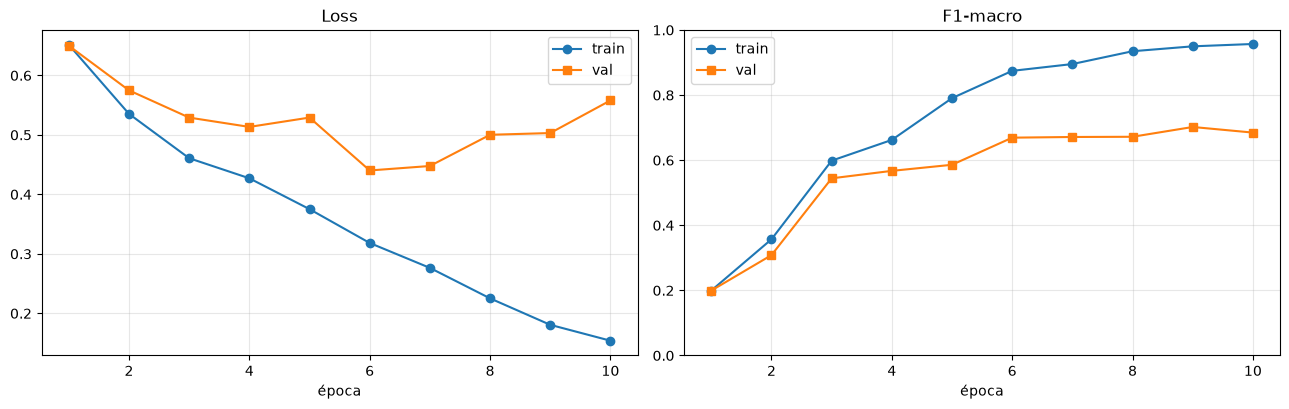

In [8]:
h = pd.read_csv(ART["hist"]); fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(h.epoch, h.train_loss, "o-", label="train"); ax[0].plot(h.epoch, h.val_loss, "s-", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("época"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h.epoch, h.train_f1_macro, "o-", label="train"); ax[1].plot(h.epoch, h.val_f1_macro, "s-", label="val")
ax[1].set_title("F1-macro"); ax[1].set_xlabel("época"); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Media ± desviación estándar y estabilidad

In [9]:
res = pd.read_csv(ART["resumen"]); display(res)
for _, r in res.iterrows():
    print(f"  {r['modelo']}: F1-macro {r['media_f1_macro']:.4f} ± {r['std_f1_macro']:.4f}  -> {'ESTABLE' if r['estable_std<=0.03'] else 'INESTABLE'}")

,modelo,ensemble_f1_macro,ensemble_accuracy,ensemble_f1_negativo,ensemble_recall_negativo,ensemble_f1_neutro,ensemble_recall_neutro,ensemble_f1_positivo,ensemble_recall_positivo,media_f1_macro,std_f1_macro,estable_std<=0.03
0,xlmr,0.7090,0.7213,0.6364,0.6512,0.7362,0.8462,0.7545,0.6500,0.6907,0.0156,True
1,bert,0.6514,0.6705,0.5551,0.5271,0.6995,0.8688,0.6995,0.5731,0.6457,0.0085,True


  xlmr: F1-macro 0.6907 ± 0.0156  -> ESTABLE
  bert: F1-macro 0.6457 ± 0.0085  -> ESTABLE


## 9. Métricas obligatorias del candidato principal (XLM-R, ensemble calibrado)

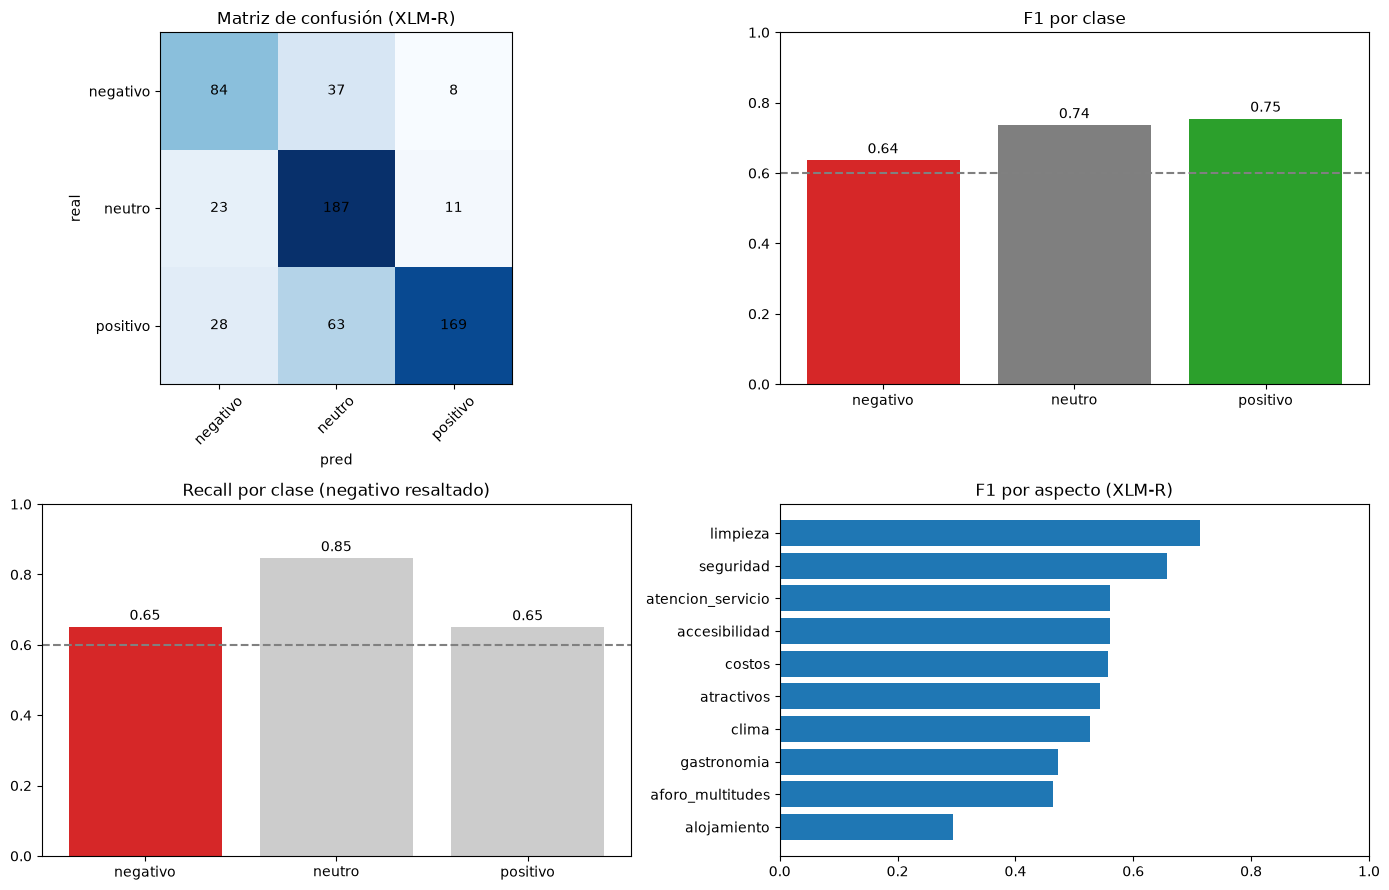

,precision,recall,f1-score,support
negativo,0.622,0.651,0.636,129.000
neutro,0.652,0.846,0.736,221.000
positivo,0.899,0.650,0.754,260.000
accuracy,0.721,0.721,0.721,0.721
macro avg,0.724,0.716,0.709,610.000
weighted avg,0.751,0.721,0.723,610.000


In [10]:
pt = pd.read_csv(ART["preds_test"]); yt, yp = pt.y_true.tolist(), pt.y_pred.tolist()
clsrep = pd.read_csv(ART["clsrep"], index_col=0); pa = pd.read_csv(ART["asp_xlmr"])
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
cm = confusion_matrix(yt, yp, labels=LABELS); ax[0,0].imshow(cm, cmap="Blues")
ax[0,0].set_xticks(range(3)); ax[0,0].set_xticklabels(LABELS, rotation=45); ax[0,0].set_yticks(range(3)); ax[0,0].set_yticklabels(LABELS)
ax[0,0].set_title("Matriz de confusión (XLM-R)"); ax[0,0].set_ylabel("real"); ax[0,0].set_xlabel("pred")
for i in range(3):
    for j in range(3): ax[0,0].text(j, i, cm[i,j], ha="center", va="center")
f1c=[clsrep.loc[l,"f1-score"] for l in LABELS]; ax[0,1].bar(LABELS, f1c, color=[COLOR[l] for l in LABELS]); ax[0,1].axhline(0.6, ls="--", color="gray"); ax[0,1].set_ylim(0,1); ax[0,1].set_title("F1 por clase")
for i,v in enumerate(f1c): ax[0,1].text(i, v+.02, f"{v:.2f}", ha="center")
rec=[clsrep.loc[l,"recall"] for l in LABELS]; ax[1,0].bar(LABELS, rec, color=["#d62728","#ccc","#ccc"]); ax[1,0].axhline(0.6, ls="--", color="gray"); ax[1,0].set_ylim(0,1); ax[1,0].set_title("Recall por clase (negativo resaltado)")
for i,v in enumerate(rec): ax[1,0].text(i, v+.02, f"{v:.2f}", ha="center")
pas=pa.sort_values("f1_macro"); ax[1,1].barh(pas.aspecto, pas.f1_macro, color="#1f77b4"); ax[1,1].set_xlim(0,1); ax[1,1].set_title("F1 por aspecto (XLM-R)")
plt.tight_layout(); plt.show(); display(clsrep.round(3))

## 10. Comparación de modelos (selección mínima)

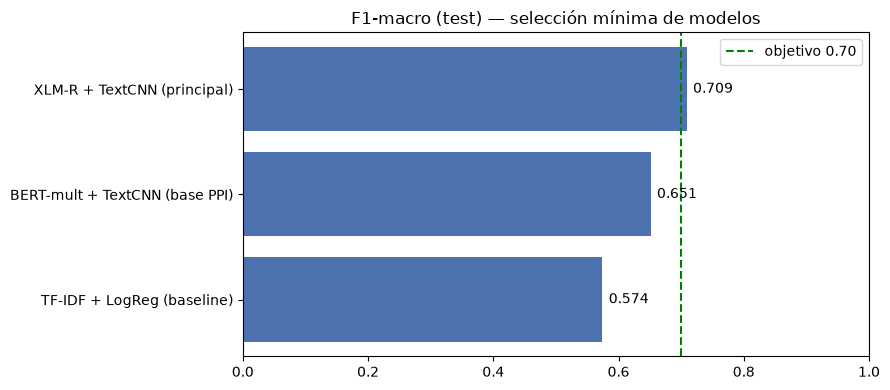

,modelo,f1_macro
0,TF-IDF + LogReg (baseline),0.5744
1,BERT-mult + TextCNN (base PPI),0.6514
2,XLM-R + TextCNN (principal),0.7090


In [11]:
comp = pd.read_csv(ART["comp"]).sort_values("f1_macro")
plt.figure(figsize=(9,4)); plt.barh(comp.modelo, comp.f1_macro, color="#4c72b0"); plt.xlim(0,1)
plt.axvline(0.70, ls="--", color="green", label="objetivo 0.70"); plt.title("F1-macro (test) — selección mínima de modelos")
for i,(_,r) in enumerate(comp.iterrows()): plt.text(r.f1_macro+.01, i, f"{r.f1_macro:.3f}", va="center")
plt.legend(); plt.tight_layout(); plt.show(); display(comp)

## 11. Comparación v3 vs v4 por aspecto (referencia de evolución)

**Nota:** v3 y v4 tienen **tests distintos** (re-partición), así que no son comparables de forma estricta.
Esto es referencia de evolución; la mejora se sostiene por aspecto y por estabilidad.

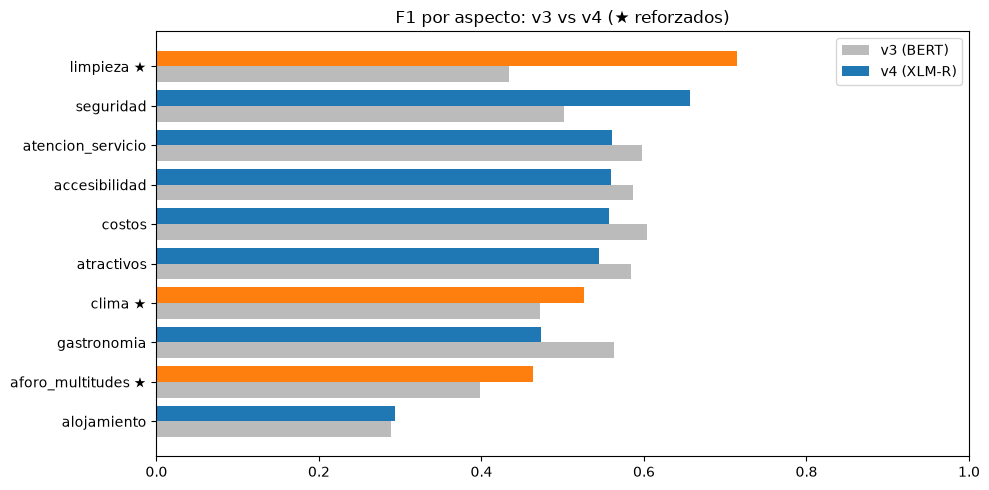

,aspecto,v3_bert,v4_xlmr
2,alojamiento,0.288,0.294
1,aforo_multitudes,0.398,0.463
7,gastronomia,0.563,0.473
5,clima,0.472,0.527
4,atractivos,0.584,0.544
6,costos,0.604,0.557
0,accesibilidad,0.587,0.560
3,atencion_servicio,0.598,0.560
9,seguridad,0.502,0.656
8,limpieza,0.433,0.714


In [12]:
pa4 = pd.read_csv(ART["asp_xlmr"]).rename(columns={"f1_macro":"v4_xlmr"})[["aspecto","v4_xlmr"]]
v3p = REP / "por_aspecto_v3.csv"
if v3p.exists():
    pa3 = pd.read_csv(v3p).rename(columns={"f1_macro":"v3_bert"})[["aspecto","v3_bert"]]
    cmp = pa3.merge(pa4, on="aspecto", how="outer").fillna(0).sort_values("v4_xlmr"); foco=["clima","aforo_multitudes","limpieza"]
    y=np.arange(len(cmp)); plt.figure(figsize=(10,5))
    plt.barh(y-0.2, cmp.v3_bert, 0.4, label="v3 (BERT)", color="#bbb")
    plt.barh(y+0.2, cmp.v4_xlmr, 0.4, label="v4 (XLM-R)", color=["#ff7f0e" if a in foco else "#1f77b4" for a in cmp.aspecto])
    plt.yticks(y, [a+(" ★" if a in foco else "") for a in cmp.aspecto]); plt.xlim(0,1); plt.legend(); plt.title("F1 por aspecto: v3 vs v4 (★ reforzados)")
    plt.tight_layout(); plt.show(); display(cmp.round(3))

## 12. Veredicto automático y selección del modelo final

Criterio: XLM-R se adopta como **modelo final** solo si cumple la spec de forma **estable**
(F1-macro ≥ 0.70, neg F1 ≥ 0.60, neg recall ≥ 0.60, neu F1 ≥ 0.60, std ≤ 0.03). Si no, se mantiene
la mejor versión defendible y se reporta XLM-R como mejora exploratoria.

In [13]:
res = pd.read_csv(ART["resumen"]).set_index("modelo")
def veredicto(tag):
    r = res.loc[tag]
    chk = {"F1-macro≥0.70": r["ensemble_f1_macro"]>=TH_MACRO, "neg F1≥0.60": r["ensemble_f1_negativo"]>=TH_NEG_F1,
           "neg recall≥0.60": r["ensemble_recall_negativo"]>=TH_NEG_REC, "neu F1≥0.60": r["ensemble_f1_neutro"]>=TH_NEU_F1,
           "estable": bool(r["estable_std<=0.03"])}
    return all(chk.values()), chk, r
for tag in ["xlmr", "bert"]:
    ok, chk, r = veredicto(tag)
    print(f"=== {tag.upper()} === F1-macro={r['ensemble_f1_macro']:.3f} neg_F1={r['ensemble_f1_negativo']:.3f} neg_rec={r['ensemble_recall_negativo']:.3f} neu_F1={r['ensemble_f1_neutro']:.3f} std={r['std_f1_macro']:.4f}")
    for k, v in chk.items(): print(f"    [{'OK' if v else 'X'}] {k}")
xlmr_ok, _, _ = veredicto("xlmr")
MODELO_FINAL = "xlmr" if xlmr_ok else ("xlmr" if res.loc["xlmr","ensemble_f1_macro"] >= res.loc["bert","ensemble_f1_macro"] else "bert")
VEREDICTO = "ÉXITO TÉCNICO (XLM-R cumple la spec de forma estable)" if xlmr_ok else "VERSIÓN BASE DEFENDIBLE (XLM-R como mejora exploratoria)"
print(f"\nMODELO PARA LA MATRIZ: {MODELO_FINAL.upper()} | {VEREDICTO}")

=== XLMR === F1-macro=0.709 neg_F1=0.636 neg_rec=0.651 neu_F1=0.736 std=0.0156
    [OK] F1-macro≥0.70
    [OK] neg F1≥0.60
    [OK] neg recall≥0.60
    [OK] neu F1≥0.60
    [OK] estable
=== BERT === F1-macro=0.651 neg_F1=0.555 neg_rec=0.527 neu_F1=0.700 std=0.0085
    [X] F1-macro≥0.70
    [X] neg F1≥0.60
    [X] neg recall≥0.60
    [OK] neu F1≥0.60
    [OK] estable

MODELO PARA LA MATRIZ: XLMR | ÉXITO TÉCNICO (XLM-R cumple la spec de forma estable)


## 13. Matriz destino-aspecto-sentimiento (modelo final)

Se genera con el modelo seleccionado arriba (XLM-R si cumple la spec de forma estable; si no, la mejor
versión defendible). Inferencia del ensemble sobre el corpus completo.

In [14]:
import sys; sys.path.append(str(BASE / "scripts"))
from generar_matriz_absa import build_matrix
if NEED_TRAIN or not ART["matriz"].exists():
    corpus = pd.read_csv(BASE / "outputs/predictions/tourism_reviews_clean_absa_ready.csv", encoding="utf-8-sig")
    if MAX_CORPUS_INFER: corpus = corpus.head(MAX_CORPUS_INFER).copy()
    if "input_modelo" not in corpus.columns or corpus["input_modelo"].isna().any():
        corpus["input_modelo"] = "aspecto: " + corpus["aspecto"].astype(str) + " reseña: " + corpus["text_clean"].astype(str)
    mname = MODEL_XLMR if MODELO_FINAL == "xlmr" else MODEL_BERT
    bpath = MODELS_DIR / f"_bias_{MODELO_FINAL}_{VER}.npy"; BIAS = np.load(bpath) if bpath.exists() else np.zeros(3)
    tok = AutoTokenizer.from_pretrained(mname)
    class InfDS(Dataset):
        def __init__(s,t): s.t=list(t)
        def __len__(s): return len(s.t)
        def __getitem__(s,i):
            e=tok(str(s.t[i]), add_special_tokens=True, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="pt")
            return {"input_ids": e["input_ids"].squeeze(0), "attention_mask": e["attention_mask"].squeeze(0)}
    cl = DataLoader(InfDS(corpus["input_modelo"]), batch_size=max(BATCH,16)); cp = np.zeros((len(corpus),3)); nseed=0
    for sd in SEEDS:
        mp = MODELS_DIR / f"modelo_{MODELO_FINAL}_seed{sd}_{VER}.pt"
        if not mp.exists(): continue
        model = TextCNN(mname).to(DEVICE); model.load_state_dict(torch.load(mp, map_location="cpu")); model.eval(); nseed+=1; pos=0
        with torch.no_grad():
            for b in cl:
                with torch.autocast("cuda", enabled=USE_AMP):
                    lo = model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE))
                pr = torch.softmax(lo.float(),1).cpu().numpy(); cp[pos:pos+len(pr)] += pr; pos+=len(pr)
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    cp /= max(nseed,1); corpus["label_pred"] = apply_bias(cp, BIAS)
    corpus[["review_uid","destination","aspecto","label_pred"]].to_csv(PRED_DIR / f"predicciones_corpus_{VER}.csv", index=False, encoding="utf-8-sig")
    matriz = build_matrix(corpus[["review_uid","destination","aspecto","label_pred"]])
    matriz.to_csv(ART["matriz"], index=False, encoding="utf-8-sig"); matriz.to_json(MATR_DIR / "matriz_destino_aspecto_sentimiento.json", orient="records", force_ascii=False, indent=2)
matriz = pd.read_csv(ART["matriz"]); print("Matriz:", matriz.shape); display(matriz.head(12))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Matriz: (100, 16)


,destination,aspecto,n_menciones,n_reseñas_únicas,n_pos,n_neu,n_neg,pct_pos,pct_neu,pct_neg,sentiment_score,score_ajustado,dominant_label,evidence_status,confidence,conflict_flag
0,Centro Histórico de Lima,accesibilidad,146,146,37,91,18,0.2534,0.6233,0.1233,0.1301,0.1301,neutro,suficiente,1.0,0
1,Centro Histórico de Lima,aforo_multitudes,214,214,17,89,108,0.0794,0.4159,0.5047,-0.4252,-0.4252,negativo,suficiente,1.0,0
2,Centro Histórico de Lima,alojamiento,18,18,3,15,0,0.1667,0.8333,0.0000,0.1667,0.1667,neutro,suficiente,1.0,0
3,Centro Histórico de Lima,atencion_servicio,106,106,27,77,2,0.2547,0.7264,0.0189,0.2358,0.2358,neutro,suficiente,1.0,0
4,Centro Histórico de Lima,atractivos,984,984,980,0,4,0.9959,0.0000,0.0041,0.9919,0.9919,positivo,suficiente,1.0,0
5,Centro Histórico de Lima,clima,33,33,1,24,8,0.0303,0.7273,0.2424,-0.2121,-0.2121,neutro,suficiente,1.0,0
6,Centro Histórico de Lima,costos,71,71,30,29,12,0.4225,0.4085,0.1690,0.2535,0.2535,positivo,suficiente,1.0,0
7,Centro Histórico de Lima,gastronomia,222,222,77,145,0,0.3468,0.6532,0.0000,0.3468,0.3468,neutro,suficiente,1.0,0
8,Centro Histórico de Lima,limpieza,221,221,199,9,13,0.9005,0.0407,0.0588,0.8416,0.8416,positivo,suficiente,1.0,0
9,Centro Histórico de Lima,seguridad,305,305,148,134,23,0.4852,0.4393,0.0754,0.4098,0.4098,positivo,suficiente,1.0,0


## 14. Vistas de la matriz: niveles de evidencia y heatmap destino × aspecto

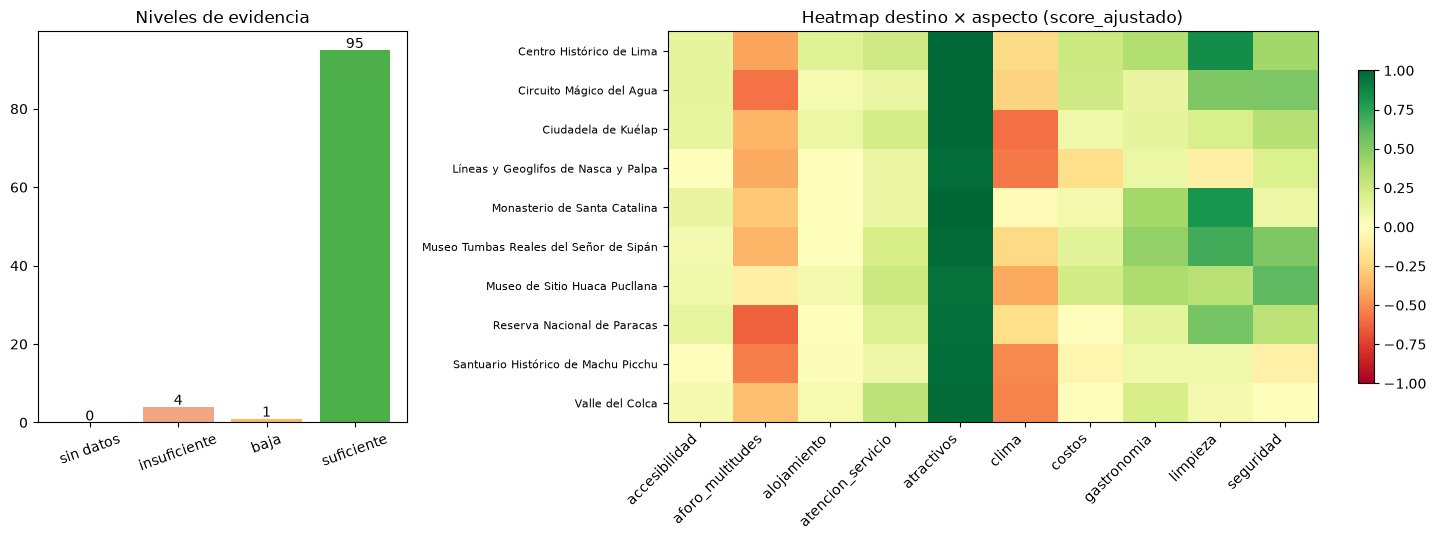

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios":[1,2.2]})
orden=["sin datos","insuficiente","baja","suficiente"]; ev=matriz["evidence_status"].value_counts().reindex(orden, fill_value=0)
ax[0].bar(ev.index, ev.values, color=["#ccc","#f4a582","#fdb863","#4daf4a"]); ax[0].set_title("Niveles de evidencia"); ax[0].tick_params(axis="x", rotation=20)
for i,v in enumerate(ev.values): ax[0].text(i, v+0.5, int(v), ha="center")
piv = matriz.pivot(index="destination", columns="aspecto", values="score_ajustado")
im = ax[1].imshow(piv.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax[1].set_xticks(range(len(piv.columns))); ax[1].set_xticklabels(piv.columns, rotation=45, ha="right")
ax[1].set_yticks(range(len(piv.index))); ax[1].set_yticklabels(piv.index, fontsize=8); ax[1].set_title("Heatmap destino × aspecto (score_ajustado)")
fig.colorbar(im, ax=ax[1], shrink=0.8); plt.tight_layout(); plt.show()

## 15. Conclusión

In [16]:
res = pd.read_csv(ART["resumen"]).set_index("modelo"); rx = res.loc["xlmr"]
print("CONCLUSIÓN"); print("-"*64)
print(f"Gold {VER} ({len(gold)} ítems, split 70/15/15 sin fuga, {len(SEEDS)} semillas, HP por validación).")
print(f"XLM-R (principal): F1-macro={rx['ensemble_f1_macro']:.3f} (media {rx['media_f1_macro']:.3f}±{rx['std_f1_macro']:.4f}), "
      f"neg F1={rx['ensemble_f1_negativo']:.3f} recall={rx['ensemble_recall_negativo']:.3f}, neu F1={rx['ensemble_f1_neutro']:.3f}")
print(f"BERT (base PPI): F1-macro={res.loc['bert','ensemble_f1_macro']:.3f}")
print(f"VEREDICTO: {VEREDICTO} | Matriz generada con: {MODELO_FINAL.upper()}")

CONCLUSIÓN
----------------------------------------------------------------
Gold v4 (4045 ítems, split 70/15/15 sin fuga, 5 semillas, HP por validación).
XLM-R (principal): F1-macro=0.709 (media 0.691±0.0156), neg F1=0.636 recall=0.651, neu F1=0.736
BERT (base PPI): F1-macro=0.651
VEREDICTO: ÉXITO TÉCNICO (XLM-R cumple la spec de forma estable) | Matriz generada con: XLMR


**Cierre metodológico.** XLM-R + TextCNN es el **candidato principal**; BERT multilingual + TextCNN
se mantiene como **arquitectura base oficial del PPI** (comparación directa). Los hiperparámetros de la
clase negativa se seleccionaron **en validación**, no en test. v3 y v4 no son comparables de forma
estricta (tests distintos): v3 es el resultado defendible de la arquitectura base; XLM-R sobre v4 es el
candidato empírico final **solo si** mantiene F1-macro ≥ 0.70 y los mínimos por clase en 5 semillas.
La matriz ABSA final se genera con el modelo que cumple la spec de forma estable; si ninguno cruza el
umbral, se reporta la mejor versión defendible y se declaran sus límites (p. ej. `alojamiento`, R20).